In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# We will calculate the 1-day 99% VaR and ES of a portfolio worth $10m consisting of investments in four stock indices as in John Hull's textbook

tickers = ['^GSPC', '^FTSE', '^FCHI', '^N225'] # S&P 500 (USA), FTSE 100 (UK), CAC 40 (France), Nikkei 225 (Japan)
weights = np.array([0.25, 0.25, 0.25, 0.25]) # assume it is an equally weighted portfolio
portfolio_value = 10_000_000
confidence_level = 0.99 
time_horizon = 1

# Get the data
start_date = '2020-01-01'
end_date = '2025-12-31'
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
data = data.ffill() # replace missing data (e.g. due to holidays) with the last valid observation forward (ffill)

log_returns = np.log(data / data.shift(1)).dropna()


[*********************100%***********************]  4 of 4 completed


In [3]:
# Historical simulation method

portfolio_returns = log_returns.dot(weights) # matrix multiplication
sorted_returns = portfolio_returns.sort_values(ascending=True) # sort returns from lowest (worst loss) to highest
cutoff_time_index = int((1 - confidence_level) * len(sorted_returns)) # the bottom 1% of returns

# VaR is the return at the cutoff index
var_percent = -sorted_returns.iloc[cutoff_time_index]
var_dollar = portfolio_value * var_percent * np.sqrt(time_horizon)

# ES is the average of all returns worse than the VaR
es_percent = -sorted_returns.iloc[:cutoff_time_index].mean()
es_dollar = portfolio_value * es_percent * np.sqrt(time_horizon)

print(f"--- Historical Method  ---")
print(f"VaR: ${var_dollar:,.2f}")
print(f"ES:  ${es_dollar:,.2f}")

--- Historical Method  ---
VaR: $281,187.96
ES:  $464,082.69


In [4]:
# Parametric method (variance-covariance matrix)
# This method assumes returns are normally distributed

cov_matrix = log_returns.cov()
avg_return = log_returns.mean().dot(weights)
    
# Calculate the portfolio volatility sqrt(w.T * Cov * w)
portfolio_std = np.sqrt(weights.T.dot(cov_matrix).dot(weights))
    
# Calculate z-score
z_score = norm.ppf(1 - confidence_level) # ppf is the quantile function; it returns a standard deviation multiplier for what value that percentage occurs at, e.g. around 2.326 in the current example

var_percent_1 = -(avg_return + z_score * portfolio_std)
var_dollar_1 = portfolio_value * var_percent_1 * np.sqrt(time_horizon)

# ES closed formula = mu + sigma * (pdf(ppf(alpha)) / (1-alpha))
es_percent_1 = -(avg_return - portfolio_std * (norm.pdf(z_score) / (1 - confidence_level)))
es_dollar_1 = portfolio_value * es_percent_1 * np.sqrt(time_horizon)

print(f"--- Parametric Method ---")
print(f"VaR: ${var_dollar_1:,.2f}")
print(f"ES:  ${es_dollar_1:,.2f}")

--- Parametric Method ---
VaR: $215,363.26
ES:  $247,226.26


In [5]:
# Monte Carlo simulation

simulations = 10000

mean_returns = log_returns.mean().values
cov_matrix = log_returns.cov().values

# Cholesky decomposition: L is a lower triangular matrix such that L * L.T = Covariance Matrix
L = np.linalg.cholesky(cov_matrix)

uncorrelated_randoms = np.random.normal(0, 1, (len(weights), simulations)) # uncorrelated random variables (standard normal)
correlated_returns = mean_returns[:, np.newaxis] + np.dot(L, uncorrelated_randoms) # correlated returns = mean + L * uncorrelated randoms
simulated_portfolio_returns = np.dot(weights, correlated_returns)
sorted_sim_returns = np.sort(simulated_portfolio_returns)
cutoff_index = int((1 - confidence_level) * simulations)

var_percent_2 = -sorted_sim_returns[cutoff_index]
var_dollar_2 = portfolio_value * var_percent_2 * np.sqrt(time_horizon)

es_percent_2 = -sorted_sim_returns[:cutoff_index].mean()
es_dollar_2 = portfolio_value * es_percent_2 * np.sqrt(time_horizon)

print(f"--- Monte Carlo Method ({simulations} Simulations) ---")
print(f"VaR: ${var_dollar_2:,.2f}")
print(f"ES:  ${es_dollar_2:,.2f}")

--- Monte Carlo Method (10000 Simulations) ---
VaR: $210,615.04
ES:  $240,941.00


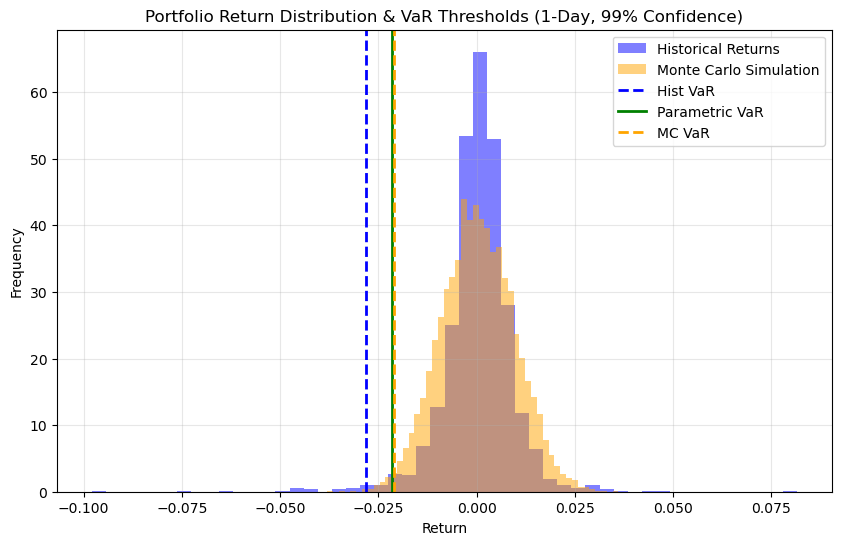

In [6]:
# Visualizing the results

plt.figure(figsize=(10, 6))

# Plot historical return distribution
plt.hist(sorted_returns, bins=50, alpha=0.5, label='Historical Returns', density=True, color='blue')

# Plot Monte Carlo simulated return distribution
plt.hist(sorted_sim_returns, bins=50, alpha=0.5, label='Monte Carlo Simulation', density=True, color='orange')

# Add vertical lines for VaR
plt.axvline(-var_dollar/portfolio_value, color='blue', linestyle='--', linewidth=2, label='Hist VaR')
plt.axvline(-var_dollar_1/portfolio_value, color='green', linestyle='-', linewidth=2, label='Parametric VaR')
plt.axvline(-var_dollar_2/portfolio_value, color='orange', linestyle='--', linewidth=2, label='MC VaR')

plt.title(f'Portfolio Return Distribution & VaR Thresholds ({time_horizon}-Day, {confidence_level  *100:.0f}% Confidence)')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Historical VaR is higher as the data window includes a crash like the 2020 COVID crash.
# Parametric and MS VaR are lower because real markets have fat tails. 

We will compute VaR and ES using the GARCH model and the Extreme Value Theory later. 